# Machine Learning for Thermal Engineers
## Lesson 6: Regularization (Ridge and Lasso)

Author: Srikantan Natarajan

# 1. Motivation

When machine learning models use many features, especially correlated ones, the learned coefficients can become unstable.

Regularization is a technique that penalizes large coefficients and encourages simpler, more stable models.

In this notebook we compare three models:

• Linear Regression  
• Ridge Regression  
• Lasso Regression

The goal is to observe how regularization affects model coefficients when redundant or correlated features are present.

# 2. Mathematical Background

Standard linear regression minimizes the mean squared error:

MSE = (1/N) Σ (y_actual − y_predicted)^2

Ridge regression adds a penalty on the squared magnitude of the coefficients:

Loss = MSE + λ Σ w_i^2

Lasso regression adds a penalty on the absolute magnitude of the coefficients:

Loss = MSE + λ Σ |w_i|

The regularization parameter λ controls how strongly the model penalizes large coefficients.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

np.random.seed(42)

# 3. Create a Synthetic HVAC Dataset

To keep this example educational and non-proprietary, we generate a synthetic dataset representing HVAC cooling behavior.

Features include:

- Ambient temperature
- Solar load
- Humidity
- Cabin temperature
- Set temperature
- Blower speed

We also create engineered features that introduce correlations between variables.

In [11]:
n_samples = 200

ambient_temp = np.random.uniform(25,45,n_samples)
solar_load = np.random.uniform(200,1000,n_samples)
humidity = np.random.uniform(30,80,n_samples)
cabin_temp = np.random.uniform(22,45,n_samples)
set_temp = np.random.uniform(18,24,n_samples)
blower_speed = np.random.uniform(5,10,n_samples)

noise = np.random.normal(0,0.25,n_samples)

compressor_power = (
    0.05*ambient_temp
    +0.0015*solar_load
    +0.015*humidity
    +0.12*cabin_temp
    -0.10*set_temp
    +0.08*blower_speed
    +noise
)

In [12]:
df = pd.DataFrame({
    "AmbientTemp":ambient_temp,
    "SolarLoad":solar_load,
    "Humidity":humidity,
    "CabinTemp":cabin_temp,
    "SetTemp":set_temp,
    "BlowerSpeed":blower_speed,
    "CompressorPower":compressor_power
})

df.head()

,AmbientTemp,SolarLoad,Humidity,CabinTemp,SetTemp,BlowerSpeed,CompressorPower
0,32.490802,713.625317,35.156193,25.885506,22.243432,5.925665,4.969673
1,44.014286,267.311972,75.127645,28.407578,18.915234,7.709505,5.846306
2,39.639879,329.302971,55.262619,26.071241,21.457730,9.364729,4.898042
3,36.973170,918.843351,71.322873,24.040158,21.640290,8.661124,6.180736
4,28.120373,685.143248,46.002480,24.774625,20.544784,9.032806,4.402868


# 4. Create Engineered Features

We now create additional derived variables. Some of these will be correlated with the original variables.

Examples:

TempError = CabinTemp − SetTemp  
SolarScaled = SolarLoad / 1000  
HumidityScaled = Humidity / 100  
CoolingIndex = TempError × SolarScaled

These extra variables help demonstrate how regularization behaves when features are correlated.

In [13]:
df["TempError"] = df["CabinTemp"] - df["SetTemp"]
df["SolarScaled"] = df["SolarLoad"] / 1000
df["HumidityScaled"] = df["Humidity"] / 100
df["CoolingIndex"] = df["TempError"] * df["SolarScaled"]

df.head()

,AmbientTemp,SolarLoad,Humidity,CabinTemp,SetTemp,BlowerSpeed,CompressorPower,TempError,SolarScaled,HumidityScaled,CoolingIndex
0,32.490802,713.625317,35.156193,25.885506,22.243432,5.925665,4.969673,3.642075,0.713625,0.351562,2.599077
1,44.014286,267.311972,75.127645,28.407578,18.915234,7.709505,5.846306,9.492344,0.267312,0.751276,2.537417
2,39.639879,329.302971,55.262619,26.071241,21.457730,9.364729,4.898042,4.613511,0.329303,0.552626,1.519243
3,36.973170,918.843351,71.322873,24.040158,21.640290,8.661124,6.180736,2.399868,0.918843,0.713229,2.205103
4,28.120373,685.143248,46.002480,24.774625,20.544784,9.032806,4.402868,4.229841,0.685143,0.460025,2.898047


# 4.1 Introduce Correlated and Redundant Features

To better demonstrate regularization effects, we intentionally create:

- Highly correlated variables
- Redundant features
- Slightly noisy duplicates

This simulates real-world engineering datasets where multiple signals describe similar system behavior.

In [14]:
# Strongly correlated features

df["CabinTemp_noisy"] = df["CabinTemp"] + np.random.normal(0, 0.5, len(df))

df["TempError_copy"] = df["TempError"] + np.random.normal(0, 0.2, len(df))

# Redundant feature (almost duplicate of SolarScaled)

df["SolarScaled_copy"] = df["SolarScaled"] * 1.05

# Weak/noisy feature (irrelevant)

df["RandomNoise"] = np.random.normal(0, 1, len(df))

# 5. Prepare the Feature Matrix

In [15]:
features = [
    "AmbientTemp",
    "SolarLoad",
    "Humidity",
    "CabinTemp",
    "SetTemp",
    "BlowerSpeed",
    "TempError",
    "SolarScaled",
    "HumidityScaled",
    "CoolingIndex",
    "CabinTemp_noisy",
    "TempError_copy",
    "SolarScaled_copy",
    "RandomNoise"
]

X = df[features]
y = df["CompressorPower"]

# 6. Train the Models

We train three regression models:

1. Standard Linear Regression
2. Ridge Regression
3. Lasso Regression

Ridge and Lasso include regularization penalties that discourage overly large coefficients.

In [16]:
linear_model = LinearRegression()
linear_model.fit(X,y)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X,y)

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X,y)

Lasso(alpha=0.01)

# 7. Compare Model Coefficients

In [17]:
coef_df = pd.DataFrame({
    "Feature":features,
    "Linear":linear_model.coef_,
    "Ridge":ridge_model.coef_,
    "Lasso":lasso_model.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso
0,AmbientTemp,0.052773,0.052784,0.052544
1,SolarLoad,0.001315,0.001315,0.001334
2,Humidity,0.013617,0.013632,0.013655
3,CabinTemp,0.063564,0.058227,0.033776
4,SetTemp,-0.027957,-0.023744,-0.000000
5,BlowerSpeed,0.078516,0.078241,0.073545
6,TempError,0.091521,0.081971,0.076535
7,SolarScaled,0.000001,0.000001,0.000000
8,HumidityScaled,0.000136,0.000136,0.000000
9,CoolingIndex,0.014206,0.014347,0.013542


# 8. Visualize Coefficient Behavior

The following plot compares coefficients from the three models.

Observe how:

• Ridge shrinks coefficients  
• Lasso may drive some coefficients toward zero

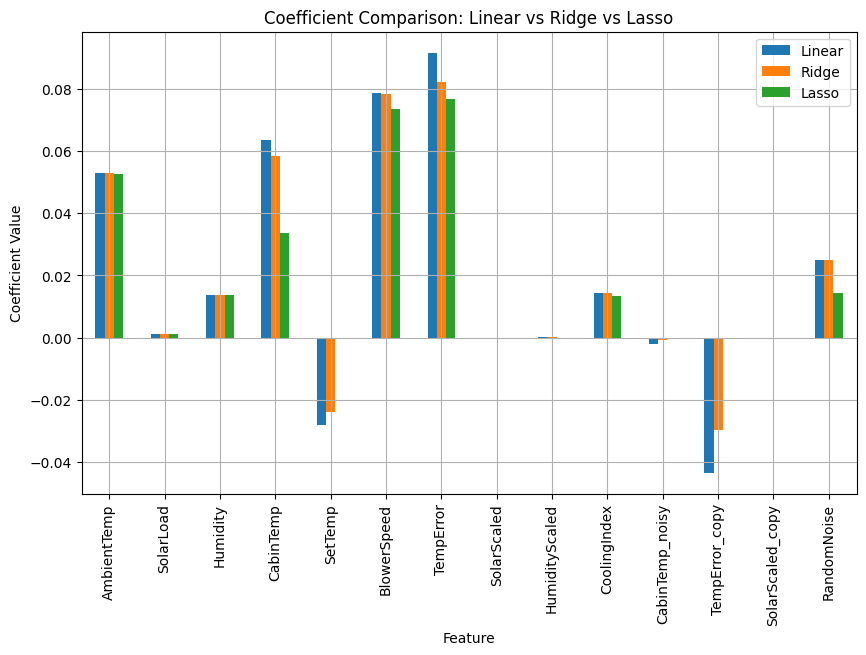

In [18]:
coef_df.set_index("Feature").plot(kind="bar", figsize=(10,6))

plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")
plt.ylabel("Coefficient Value")

plt.grid(True)
plt.show()

# 9. Key Observations

Linear regression may assign unstable coefficients when features are correlated.

Ridge regression stabilizes the solution by shrinking coefficient magnitudes.

Lasso regression performs automatic feature selection by driving some coefficients to zero.

Regularization is especially useful when working with engineering datasets containing redundant signals.

# 10. Engineering Interpretation

Engineering systems often contain correlated measurements.

Examples in HVAC systems might include:

- Cabin temperature
- Temperature error
- Equivalent temperature
- Cabin comfort error

Regularization techniques help keep the model stable when such correlated variables are present.

They also help identify which variables contribute the most useful information.

# 11. Manual Feature Selection - New Model

In [19]:
selected_features = ["TempError", "CoolingIndex"]

X_selected = df[selected_features]

model_selected = LinearRegression()
model_selected.fit(X_selected, y)

print("Coefficients:", model_selected.coef_)

Coefficients: [0.05986562 0.09704823]
